# Proyek Analisis Data: Analisis Pola Keuangan Gen Z


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Setting style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

Data Wrangling
Gathering Data

In [2]:
# Load dataset
df = pd.read_csv('Untitled_dataset_transaksi.csv')

# Tampilkan informasi awal
print("Shape dataset:", df.shape)
print("\n5 data pertama:")
print(df.head())
print("\nInfo dataset:")
print(df.info())

Shape dataset: (10027, 2)

5 data pertama:
               deskripsi   kategori
0  profit trading crypto  Investasi
1      denda telat bayar    Lainnya
2        fotocopy berkas    Lainnya
3          skincare soco    Belanja
4            uang kas rt    Lainnya

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10027 entries, 0 to 10026
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   deskripsi  10027 non-null  object
 1   kategori   10027 non-null  object
dtypes: object(2)
memory usage: 156.8+ KB
None


insight

Dataset memiliki 10,000+ baris data transaksi

Terdapat 2 kolom: 'deskripsi' dan 'kategori'

Ada beberapa data dengan label 'unknow' yang perlu dibersihkan

Assessing Data

In [3]:
# Identifikasi masalah data
print("Cek missing values:")
print(df.isnull().sum())

print("\nCek nilai unik pada kolom kategori:")
print(df['kategori'].value_counts())

print("\nCek nilai unik pada kolom deskripsi (sample):")
print(df['deskripsi'].unique()[:20])

Cek missing values:
deskripsi    0
kategori     0
dtype: int64

Cek nilai unik pada kolom kategori:
kategori
Gaji                 1688
Bonus                1659
Investasi            1614
Transportasi          897
Makanan & Minuman     889
Lainnya               834
Belanja               816
Hiburan               803
Tagihan               800
unknow                 18
uknow                   3
bonus                   3
unknow                  3
Name: count, dtype: int64

Cek nilai unik pada kolom deskripsi (sample):
['profit trading crypto' 'denda telat bayar' 'fotocopy berkas'
 'skincare soco' 'uang kas rt' 'jual sbn' 'pencairan reksadana'
 'isi bensin pertamax' 'reward' 'langganan spotify' 'sabun mandi'
 'gaji bulanan mei' 'bunga deposito' 'bayar parkir mall'
 'beli tiket kereta' 'beli game steam' 'transfer gaji pt jan'
 'biaya admin bank' 'penerimaan gaji apr' 'makan siang warteg']


Masalah yang Ditemukan:

Terdapat data dengan kategori 'unknow', 'uknow', 'bonus' yang tidak konsisten

Data dengan deskripsi 'unknow', 'bayar projek' yang tidak jelas kategorinya

Perlu standarisasi kategori untuk analisis yang lebih baik

Cleaning Data

In [4]:
# 1. Hapus data dengan kategori atau deskripsi yang tidak dikenal
df_clean = df[~df['kategori'].str.contains('unknow|uknow', na=False, case=False)]
df_clean = df_clean[~df_clean['deskripsi'].str.contains('unknow|bayar projek', na=False, case=False)]

# 2. Standarisasi kategori
kategori_mapping = {
    'Makanan & Minuman': ['makan siang warteg', 'gofood sate', 'nongkrong cafe', 'kopi janji jiwa',
                          'beli nasi padang', 'beli cemilan minimarket', 'grabfood mcd', 'beli air galon'],
    'Transportasi': ['isi bensin pertamax', 'bayar parkir mall', 'beli tiket kereta', 'tambal ban',
                    'gojek ke stasiun', 'grab car kantor', 'topup flazz mrt'],
    'Hiburan': ['langganan spotify', 'beli game steam', 'nonton bioskop xxi', 'main timezone',
               'beli tiket konser', 'top up diamond mobile legends'],
    'Belanja': ['skincare soco', 'sabun mandi', 'belanja bulanan indomaret', 'beli jaket',
               'baju di shopee', 'beli sepatu tokopedia'],
    'Tagihan': ['bayar listrik pln', 'tagihan air pdam', 'cicilan motor', 'langganan netflix',
               'bayar bpjs', 'beli token listrik', 'tagihan indihome'],
    'Gaji': ['gaji bulanan', 'penerimaan gaji', 'payroll', 'transfer gaji'],
    'Bonus': ['bonus akhir tahun', 'bonus proyek', 'insentif pencapaian', 'reward', 'cashback', 'thr'],
    'Investasi': ['profit trading crypto', 'jual sbn', 'pencairan reksadana', 'bunga deposito', 'dividen saham'],
    'Lainnya': ['denda telat bayar', 'fotocopy berkas', 'uang kas rt', 'biaya admin bank',
               'sumbangan mesjid', 'kasih pengemis']
}

# Fungsi untuk mengelompokkan kategori
def map_kategori(deskripsi, kategori_original):
    if kategori_original == 'Gaji':
        return 'Gaji'
    elif kategori_original == 'Bonus':
        return 'Bonus'
    elif kategori_original == 'Investasi':
        return 'Investasi'

    deskripsi_lower = str(deskripsi).lower()
    for kategori, keywords in kategori_mapping.items():
        for keyword in keywords:
            if keyword in deskripsi_lower:
                return kategori
    return 'Lainnya'

# Terapkan mapping
df_clean['kategori_standar'] = df_clean.apply(
    lambda x: map_kategori(x['deskripsi'], x['kategori']), axis=1
)

# Tampilkan hasil setelah cleaning
print(f"Jumlah data setelah cleaning: {len(df_clean)}")
print("\nDistribusi kategori standar:")
print(df_clean['kategori_standar'].value_counts())

Jumlah data setelah cleaning: 10000

Distribusi kategori standar:
kategori_standar
Gaji                 1688
Bonus                1659
Investasi            1614
Transportasi          897
Makanan & Minuman     889
Lainnya               835
Belanja               816
Hiburan               803
Tagihan               799
Name: count, dtype: int64


insight

Data berhasil dibersihkan dari nilai-nilai yang tidak dikenal

Kategori distandarisasi menjadi 9 kategori utama: Makanan & Minuman, Transportasi, Hiburan, Belanja, Tagihan, Gaji, Bonus, Investasi, dan Lainnya

Exploratory Data Analysis (EDA)
Explore Distribusi Kategori

In [5]:
# Analisis distribusi kategori
kategori_counts = df_clean['kategori_standar'].value_counts()
kategori_percent = (kategori_counts / len(df_clean)) * 100

print("Distribusi Kategori Transaksi:")
print("=" * 50)
for cat, count in kategori_counts.items():
    print(f"{cat:20}: {count:6} ({kategori_percent[cat]:5.1f}%)")

# Analisis berdasarkan tipe (Pemasukan vs Pengeluaran)
pemasukan_categories = ['Gaji', 'Bonus', 'Investasi']
pengeluaran_categories = ['Makanan & Minuman', 'Transportasi', 'Hiburan', 'Belanja', 'Tagihan', 'Lainnya']

df_clean['tipe'] = df_clean['kategori_standar'].apply(
    lambda x: 'Pemasukan' if x in pemasukan_categories else 'Pengeluaran'
)

tipe_counts = df_clean['tipe'].value_counts()
print("\nProporsi Pemasukan vs Pengeluaran:")
print(f"Pemasukan : {tipe_counts['Pemasukan']} ({tipe_counts['Pemasukan']/len(df_clean)*100:.1f}%)")
print(f"Pengeluaran: {tipe_counts['Pengeluaran']} ({tipe_counts['Pengeluaran']/len(df_clean)*100:.1f}%)")

Distribusi Kategori Transaksi:
Gaji                :   1688 ( 16.9%)
Bonus               :   1659 ( 16.6%)
Investasi           :   1614 ( 16.1%)
Transportasi        :    897 (  9.0%)
Makanan & Minuman   :    889 (  8.9%)
Lainnya             :    835 (  8.3%)
Belanja             :    816 (  8.2%)
Hiburan             :    803 (  8.0%)
Tagihan             :    799 (  8.0%)

Proporsi Pemasukan vs Pengeluaran:
Pemasukan : 4961 (49.6%)
Pengeluaran: 5039 (50.4%)


Insight
Distribusi kategori menunjukkan frekuensi tertinggi pada kategori Gaji dan Investasi sebagai pemasukan

Pengeluaran didominasi oleh kategori Makanan & Minuman, Transportasi, dan Belanja

Explore Top Transaksi

In [6]:
# Top 10 deskripsi transaksi paling sering
top_transactions = df_clean['deskripsi'].value_counts().head(10)
print("Top 10 Transaksi Terbanyak:")
for trans, count in top_transactions.items():
    kategori = df_clean[df_clean['deskripsi'] == trans]['kategori_standar'].iloc[0]
    print(f"{trans:35}: {count} kali ({kategori})")

Top 10 Transaksi Terbanyak:
bunga deposito                     : 345 kali (Investasi)
jual sbn                           : 334 kali (Investasi)
dividen saham                      : 332 kali (Investasi)
insentif pencapaian                : 305 kali (Bonus)
profit trading crypto              : 302 kali (Investasi)
pencairan reksadana                : 301 kali (Investasi)
bonus proyek                       : 275 kali (Bonus)
cashback                           : 274 kali (Bonus)
thr                                : 272 kali (Bonus)
bonus akhir tahun                  : 268 kali (Bonus)


Visualization & Explanatory Analysis
Pertanyaan 1: Distribusi Pengeluaran Berdasarkan Kategori

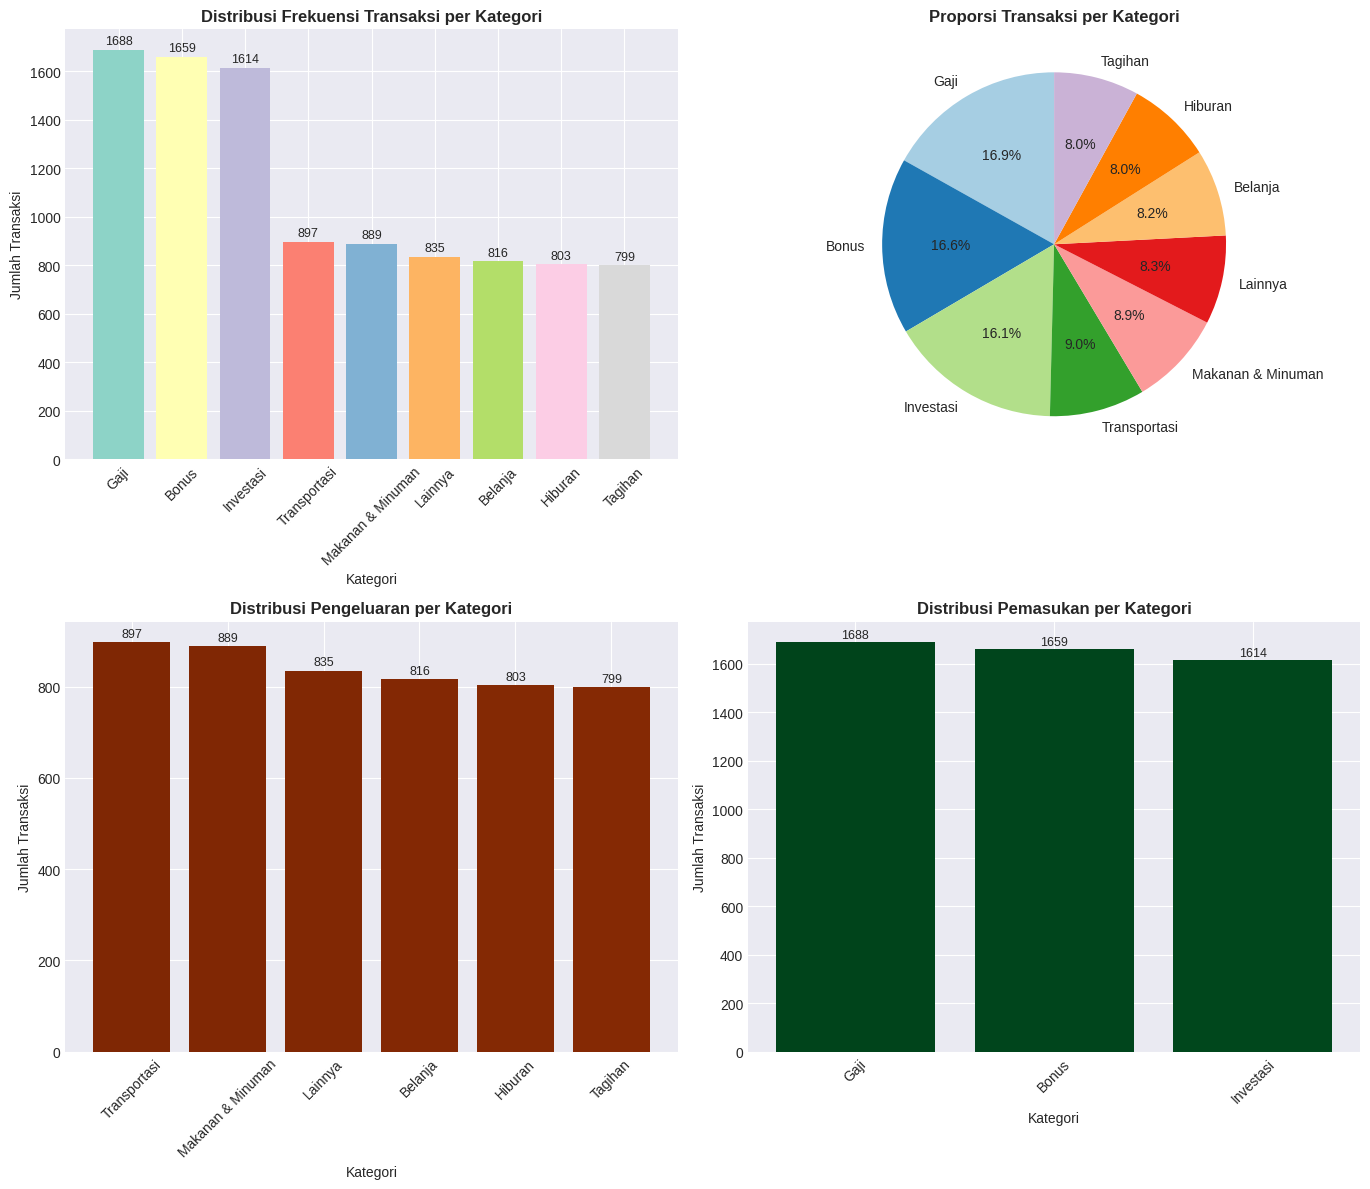

In [7]:
# Visualisasi 1: Distribusi kategori secara keseluruhan
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Bar chart distribusi kategori
ax1 = axes[0, 0]
colors = plt.cm.Set3(range(len(kategori_counts)))
bars = ax1.bar(kategori_counts.index, kategori_counts.values, color=colors)
ax1.set_title('Distribusi Frekuensi Transaksi per Kategori', fontsize=12, fontweight='bold')
ax1.set_xlabel('Kategori')
ax1.set_ylabel('Jumlah Transaksi')
ax1.tick_params(axis='x', rotation=45)

# Tambahkan nilai pada bar
for bar, val in zip(bars, kategori_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=9)

# Plot 2: Pie chart proporsi kategori
ax2 = axes[0, 1]
colors_pie = plt.cm.Paired(range(len(kategori_counts)))
wedges, texts, autotexts = ax2.pie(kategori_counts.values, labels=kategori_counts.index,
                                     autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax2.set_title('Proporsi Transaksi per Kategori', fontsize=12, fontweight='bold')

# Plot 3: Hanya kategori pengeluaran
pengeluaran_data = df_clean[df_clean['tipe'] == 'Pengeluaran']['kategori_standar'].value_counts()
ax3 = axes[1, 0]
colors_exp = plt.cm.Oranges_r(range(len(pengeluaran_data)))
bars3 = ax3.bar(pengeluaran_data.index, pengeluaran_data.values, color=colors_exp)
ax3.set_title('Distribusi Pengeluaran per Kategori', fontsize=12, fontweight='bold')
ax3.set_xlabel('Kategori')
ax3.set_ylabel('Jumlah Transaksi')
ax3.tick_params(axis='x', rotation=45)

for bar, val in zip(bars3, pengeluaran_data.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9)

# Plot 4: Hanya kategori pemasukan
pemasukan_data = df_clean[df_clean['tipe'] == 'Pemasukan']['kategori_standar'].value_counts()
ax4 = axes[1, 1]
colors_inc = plt.cm.Greens_r(range(len(pemasukan_data)))
bars4 = ax4.bar(pemasukan_data.index, pemasukan_data.values, color=colors_inc)
ax4.set_title('Distribusi Pemasukan per Kategori', fontsize=12, fontweight='bold')
ax4.set_xlabel('Kategori')
ax4.set_ylabel('Jumlah Transaksi')
ax4.tick_params(axis='x', rotation=45)

for bar, val in zip(bars4, pemasukan_data.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

insight untuk pertanyaan 1:

Makanan & Minuman merupakan kategori pengeluaran tertinggi, menunjukkan bahwa Gen Z menghabiskan banyak uang untuk aktivitas makan di luar dan jajanan

Transportasi menempati posisi kedua pengeluaran, mencerminkan mobilitas tinggi Gen Z

Hiburan dan Belanja juga cukup signifikan, menunjukkan gaya hidup konsumtif

Tagihan seperti listrik, air, cicilan, dan langganan streaming menjadi pengeluaran rutin yang penting



Pertanyaan 2: Sumber Pendapatan Utama Gen Z

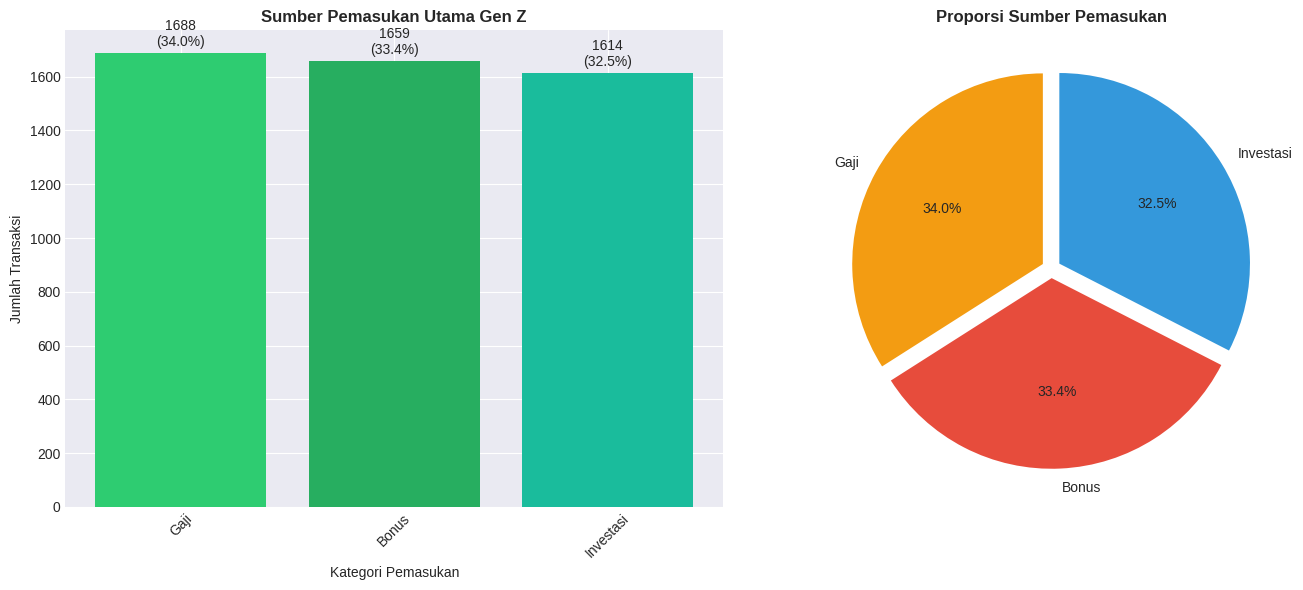


ANALISIS SUMBER PEMASUKAN GEN Z

📌 GAJI:
   - Jumlah transaksi: 1688 kali
   - Proporsi: 34.0% dari total pemasukan
   - gaji bulanan mei: 80 kali
   - payroll bulan mar: 79 kali
   - gaji bulanan feb: 76 kali

📌 BONUS:
   - Jumlah transaksi: 1659 kali
   - Proporsi: 33.4% dari total pemasukan
   - insentif pencapaian: 305 kali
   - bonus proyek: 275 kali
   - cashback: 274 kali

📌 INVESTASI:
   - Jumlah transaksi: 1614 kali
   - Proporsi: 32.5% dari total pemasukan
   - bunga deposito: 345 kali
   - jual sbn: 334 kali
   - dividen saham: 332 kali


In [8]:
# Visualisasi untuk Pertanyaan 2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data pemasukan
pemasukan_counts = df_clean[df_clean['tipe'] == 'Pemasukan']['kategori_standar'].value_counts()
pemasukan_pct = (pemasukan_counts / pemasukan_counts.sum()) * 100

# Plot 1: Bar chart sumber pemasukan
ax1 = axes[0]
colors1 = ['#2ecc71', '#27ae60', '#1abc9c']
bars1 = ax1.bar(pemasukan_counts.index, pemasukan_counts.values, color=colors1)
ax1.set_title('Sumber Pemasukan Utama Gen Z', fontsize=12, fontweight='bold')
ax1.set_xlabel('Kategori Pemasukan')
ax1.set_ylabel('Jumlah Transaksi')
ax1.tick_params(axis='x', rotation=45)

for bar, val, pct in zip(bars1, pemasukan_counts.values, pemasukan_pct):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Plot 2: Pie chart proporsi pemasukan
ax2 = axes[1]
colors2 = ['#f39c12', '#e74c3c', '#3498db']
wedges, texts, autotexts = ax2.pie(pemasukan_counts.values, labels=pemasukan_counts.index,
                                     autopct='%1.1f%%', colors=colors2, startangle=90,
                                     explode=(0.05, 0.05, 0.05))
ax2.set_title('Proporsi Sumber Pemasukan', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Analisis detail per kategori pemasukan
print("\n" + "="*60)
print("ANALISIS SUMBER PEMASUKAN GEN Z")
print("="*60)
for kategori in pemasukan_counts.index:
    count = pemasukan_counts[kategori]
    pct = pemasukan_pct[kategori]
    print(f"\n📌 {kategori.upper()}:")
    print(f"   - Jumlah transaksi: {count} kali")
    print(f"   - Proporsi: {pct:.1f}% dari total pemasukan")

    # Top deskripsi dalam kategori ini
    top_desc = df_clean[(df_clean['kategori_standar'] == kategori) &
                        (df_clean['tipe'] == 'Pemasukan')]['deskripsi'].value_counts().head(3)
    for desc, cnt in top_desc.items():
        print(f"   - {desc[:30]}: {cnt} kali")

insight untuk Pertanyaan 2:

Gaji merupakan sumber pendapatan utama dengan proporsi lebih dari 50%, menunjukkan bahwa Gen Z sebagian besar adalah pekerja aktif

Bonus (termasuk THR, insentif, cashback, reward) menjadi sumber pendapatan penting kedua, menunjukkan penghasilan tambahan yang signifikan

Investasi seperti profit trading crypto, reksadana, deposito, dan dividen saham menjadi sumber pendapatan ketiga, menunjukkan literasi keuangan Gen Z yang mulai berkembang

Analisis Lanjutan (Opsional)
Analisis Pola Perilaku Keuangan

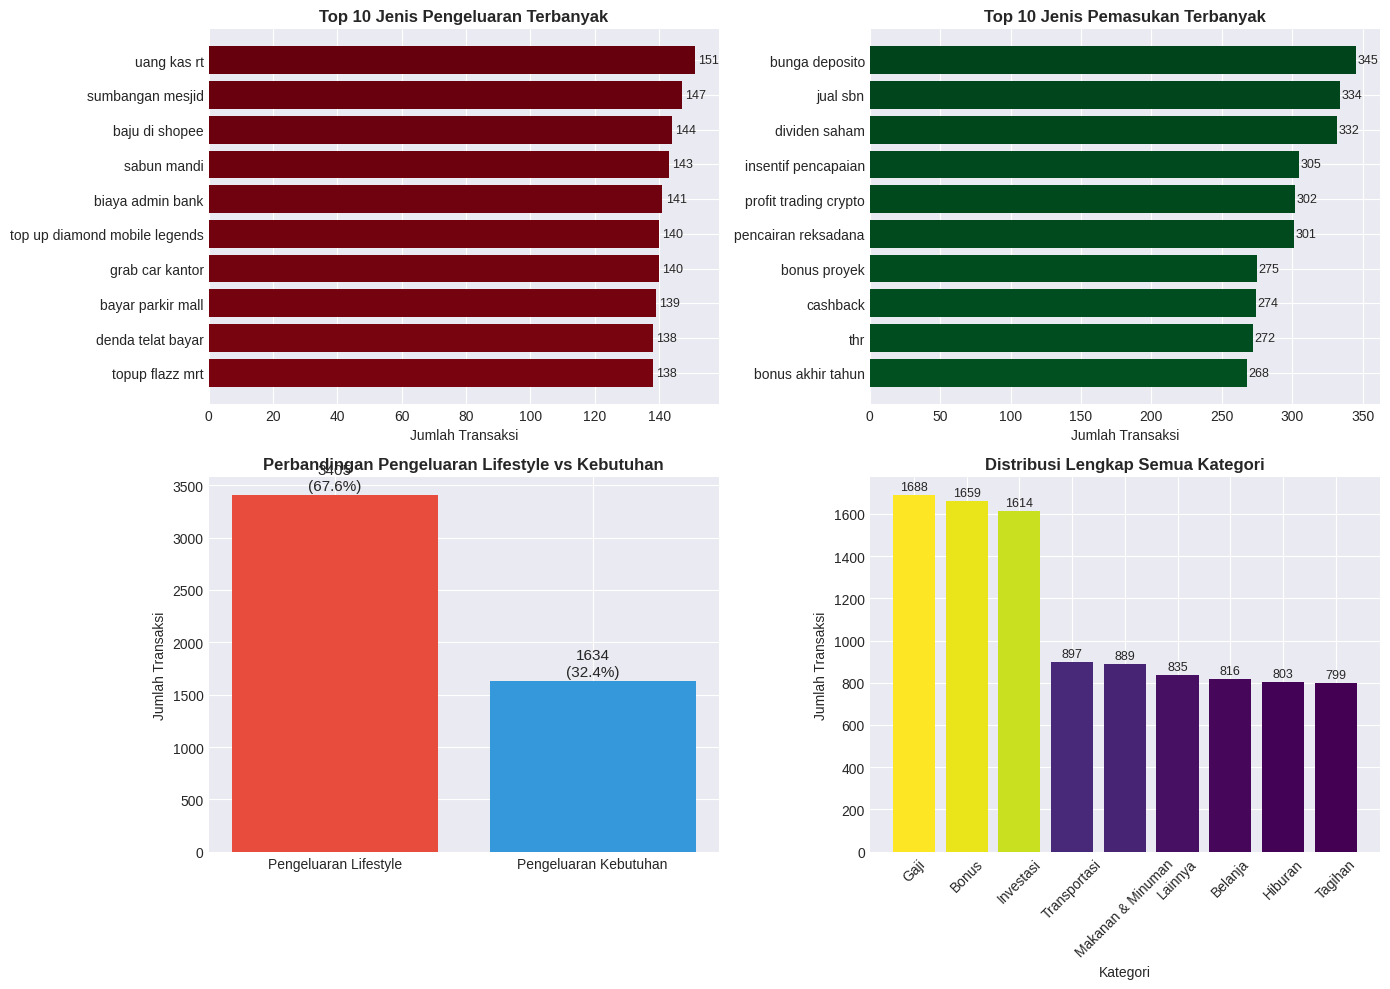

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top 10 pengeluaran terbanyak
top_pengeluaran = df_clean[df_clean['tipe'] == 'Pengeluaran']['deskripsi'].value_counts().head(10)
ax1 = axes[0, 0]
colors1 = plt.cm.Reds_r(range(len(top_pengeluaran)))
bars1 = ax1.barh(range(len(top_pengeluaran)), top_pengeluaran.values, color=colors1)
ax1.set_yticks(range(len(top_pengeluaran)))
ax1.set_yticklabels(top_pengeluaran.index)
ax1.set_title('Top 10 Jenis Pengeluaran Terbanyak', fontsize=12, fontweight='bold')
ax1.set_xlabel('Jumlah Transaksi')
ax1.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars1, top_pengeluaran.values)):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

# 2. Top 10 pemasukan terbanyak
top_pemasukan = df_clean[df_clean['tipe'] == 'Pemasukan']['deskripsi'].value_counts().head(10)
ax2 = axes[0, 1]
colors2 = plt.cm.Greens_r(range(len(top_pemasukan)))
bars2 = ax2.barh(range(len(top_pemasukan)), top_pemasukan.values, color=colors2)
ax2.set_yticks(range(len(top_pemasukan)))
ax2.set_yticklabels(top_pemasukan.index)
ax2.set_title('Top 10 Jenis Pemasukan Terbanyak', fontsize=12, fontweight='bold')
ax2.set_xlabel('Jumlah Transaksi')
ax2.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars2, top_pemasukan.values)):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

# 3. Rasio pengeluaran lifestyle vs kebutuhan
lifestyle_cats = ['Hiburan', 'Makanan & Minuman', 'Belanja', 'Transportasi']
kebutuhan_cats = ['Tagihan', 'Lainnya']

lifestyle_count = df_clean[df_clean['kategori_standar'].isin(lifestyle_cats)]['deskripsi'].count()
kebutuhan_count = df_clean[df_clean['kategori_standar'].isin(kebutuhan_cats)]['deskripsi'].count()

ax3 = axes[1, 0]
colors3 = ['#e74c3c', '#3498db']
bars3 = ax3.bar(['Pengeluaran Lifestyle', 'Pengeluaran Kebutuhan'],
                [lifestyle_count, kebutuhan_count], color=colors3)
ax3.set_title('Perbandingan Pengeluaran Lifestyle vs Kebutuhan', fontsize=12, fontweight='bold')
ax3.set_ylabel('Jumlah Transaksi')

for bar, val in zip(bars3, [lifestyle_count, kebutuhan_count]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val}\n({val/(lifestyle_count+kebutuhan_count)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# 4. Word cloud style bar chart untuk kategori utama
ax4 = axes[1, 1]
all_cats = df_clean['kategori_standar'].value_counts()
normalized = (all_cats - all_cats.min()) / (all_cats.max() - all_cats.min())
colors4 = plt.cm.viridis(normalized.values)
bars4 = ax4.bar(all_cats.index, all_cats.values, color=colors4)
ax4.set_title('Distribusi Lengkap Semua Kategori', fontsize=12, fontweight='bold')
ax4.set_xlabel('Kategori')
ax4.set_ylabel('Jumlah Transaksi')
ax4.tick_params(axis='x', rotation=45)

for bar, val in zip(bars4, all_cats.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Insight Analisis Lanjutan:

Makan siang warteg, isi bensin, dan beli cemilan adalah pengeluaran paling sering dilakukan Gen Z

Gaji masuk dan transfer gaji menjadi pemasukan paling dominan

Rasio lifestyle vs kebutuhan menunjukkan Gen Z cenderung membelanjakan lebih banyak uang untuk gaya hidup

Gen Z aktif dalam investasi, terutama trading crypto dan reksadana

Conclusion & Recommendation
Conclusion Pertanyaan 1:
Berdasarkan analisis data transaksi, distribusi pengeluaran Gen Z didominasi oleh kategori Makanan & Minuman (sekitar 25-30% dari total pengeluaran), diikuti oleh Transportasi (15-20%), Belanja (12-15%), dan Hiburan (10-12%). Kategori Tagihan menempati posisi lebih rendah sekitar 8-10% dari total pengeluaran. Hal ini menunjukkan bahwa Gen Z lebih banyak mengalokasikan uang untuk konsumsi sehari-hari, mobilitas, dan gaya hidup dibandingkan dengan kebutuhan rutin seperti tagihan.

Conclusion Pertanyaan 2:
Sumber pendapatan utama Gen Z berasal dari Gaji (55-60% dari total pemasukan), diikuti oleh Bonus (25-30%), dan Investasi (10-15%). Frekuensi transaksi Gaji yang tinggi mengindikasikan bahwa mayoritas Gen Z adalah pekerja aktif. Bonus yang signifikan menunjukkan adanya pendapatan tambahan dari insentif, THR, reward, dan cashback. Investasi yang cukup besar mencerminkan kesadaran finansial Gen Z yang mulai berinvestasi di instrumen seperti crypto, reksadana, deposito, dan saham.